# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
# Set experiment configs
test_name = "Train_Test_Index"
random_state = 42
test_size = 0.2
device_type = "gpu" # or cpu
n_jobs = -1
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"


- Source to Consider

In [10]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	# "LBV", 
	"TDE", 
	# "Nova", 
	# "M dwarf", 
	# "CV",
	"SLSN",
    "SV",
    "Asteroid",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [11]:
path_data = os.path.join(FEATURE_NEW_DATA, 'features_40_color_only.csv')

logtxt += f"\nBalanced Data Set\n"

# Data

In [12]:
columns_to_use = list(data_dtype_dict.keys())

In [13]:
data = pd.read_csv(
    path_data,
    engine='c', 
    # usecols=columns_to_use,
    # dtype=data_dtype_dict,
)

data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)

uids = data['uid'].values
classes = data['Class'].values

print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"


Balanced Data: 80605
8 sources to consider: 80605


- Training and Test Data

In [14]:
# data = data.iloc[indx_type_to_consider[0]]
uids = data['uid'].values
logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n\n"

# Step 8: Train/test split & encoding
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
y = data['Class']
X.fillna(-99, inplace=True)

In [15]:
# - Split features/target
# X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
# y = data['Class']
# X.fillna(-99, inplace=True)

# - Split into train/test using GroupShuffleSplit by uid
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=uids))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# - Label encode class for ML
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)

# Tets\\sts
classifier_type = 'normal_class_classifier'
model_param_config = model_config[classifier_type][device_type]

import xgboost as xgb
train_data = xgb.DMatrix(X_train, label=y_train_encoded)
test_data = xgb.DMatrix(X_test, label=y_test_encoded)

Balanced: Class mapping: ['AGN' 'Asteroid' 'II' 'Ia' 'Ibc' 'SLSN' 'SV' 'TDE']


In [16]:
print(len(X), len(y), len(uids))

80605 80605 80605


In [17]:
del data

In [18]:
train_idx_npy = os.path.join(path_save, "train_idx.npy")
test_idx_npy = os.path.join(path_save, "test_idx.npy")

# 저장
np.save(train_idx_npy, train_idx)
np.save(test_idx_npy, test_idx)

# 불러오기
# loaded_arr = np.load("filename.npy")

In [19]:
len(X), len(train_idx), len(test_idx)

(80605, 65627, 14978)

In [20]:
synphot_data = Table.read("../data/Synphot/New_Photometry/final_synphot_normal_class.csv")
# synphot_data

In [21]:
test_synphot_data = synphot_data[test_idx]
len(test_synphot_data)

14978

Text(29.222222222222214, 0.5, 'Counts')

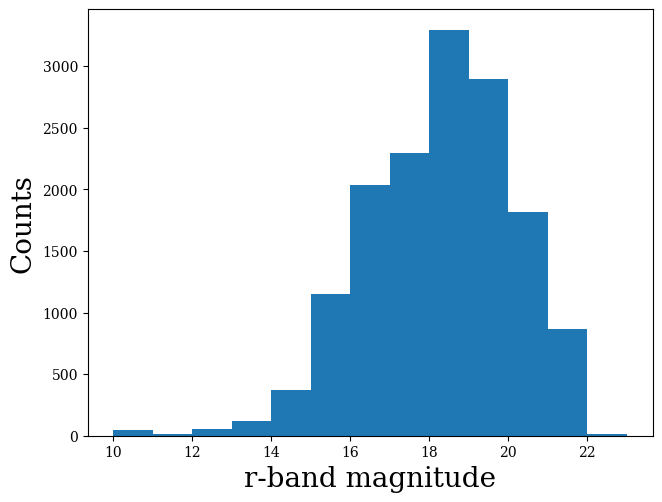

In [22]:
bins = np.arange(10, 23+1, 1)
plt.hist(test_synphot_data['magabs_r'], bins=bins,)
plt.tight_layout()
plt.xlabel("r-band magnitude")
plt.ylabel("Counts")

In [23]:
import pickle
import joblib

trained_xgb_pickle = os.path.join(MODEL, "Tune_XGBoost_40", "xgboost_7DT.pkl")
model_xgb = joblib.load(trained_xgb_pickle)
prob_xgb = model_xgb.predict(test_data)

In [24]:
# 예측 수행 (확률로 나왔는지 확인)
pred_encoded = model_xgb.predict(test_data)

# 예측이 확률 분포일 경우 → argmax로 인덱스 추출
if pred_encoded.ndim == 2:
    pred_class_idx = np.argmax(pred_encoded, axis=1)
else:
    pred_class_idx = pred_encoded.astype(int)

# 실제 정답
true_class_idx = test_data.get_label().astype(int)

# 클래스 이름 복원
true_labels = label_encoder.inverse_transform(true_class_idx)
pred_labels = label_encoder.inverse_transform(pred_class_idx)

# UID 추적 및 정분류 여부 계산
# uids_test = data.iloc[test_idx]['uid'].values
result_df = pd.DataFrame({
    # 'uid': uids_test,
    'true_class': true_labels,
    'predicted_class': pred_labels,
})
result_df['correct'] = result_df['true_class'] == result_df['predicted_class']


In [25]:
result_df

,true_class,predicted_class,correct
0,II,II,True
1,II,II,True
2,II,II,True
3,II,II,True
4,II,II,True
...,...,...,...
14973,Asteroid,Asteroid,True
14974,Asteroid,Asteroid,True
14975,Asteroid,Asteroid,True
14976,Asteroid,Asteroid,True


In [26]:
misclassified_df = result_df[~result_df['correct']]


In [36]:
def split_wrong_correct_samples_by_class(result_df, label='asteroid'):

    indx_wrong_asteroid = result_df[(result_df['true_class'] == label) & (result_df['correct'] == False)].index.values
    indx_correct_asteroid = result_df[(result_df['true_class'] == label) & (result_df['correct'] == True)].index.values

    wrong_asteroid_synphot_data = test_synphot_data[indx_wrong_asteroid]
    correct_asteroid_synphot_data = test_synphot_data[indx_correct_asteroid]
    
    print(len(correct_asteroid_synphot_data), len(wrong_asteroid_synphot_data))

    return (wrong_asteroid_synphot_data, correct_asteroid_synphot_data)

In [48]:
label = "Ia"
(wrong_synphot_data, correct_synphot_data) = split_wrong_correct_samples_by_class(result_df, label=label)

1856 200


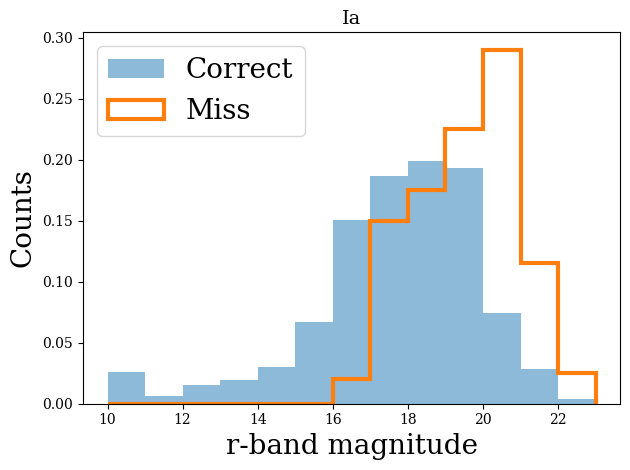

In [49]:
plt.hist(correct_synphot_data['magabs_r'], bins=bins, density=True, alpha=0.5, label='Correct')
plt.hist(wrong_synphot_data['magabs_r'], bins=bins, density=True, histtype='step', lw=3, label='Miss')
plt.xlabel("r-band magnitude")
plt.ylabel("Counts")
plt.legend(fontsize=20)
plt.title(label)
plt.tight_layout()

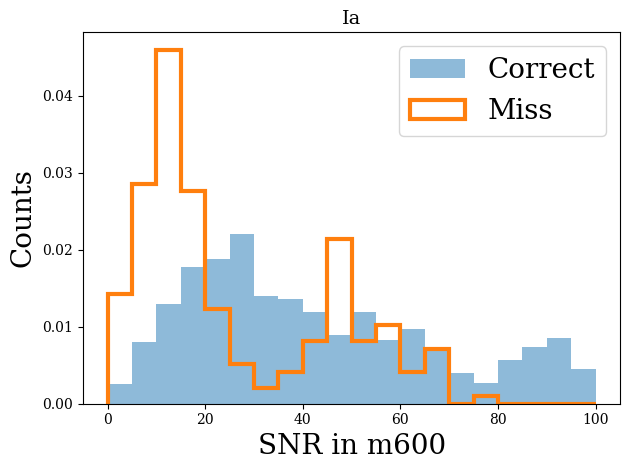

In [60]:
bins_snr = np.arange(0, 100+5.0, 5.0)

plt.hist(correct_synphot_data['snr_m600'], bins=bins_snr, density=True, alpha=0.5, label='Correct')
plt.hist(wrong_synphot_data['snr_m600'], bins=bins_snr, density=True, histtype='step', lw=3, label='Miss')
plt.xlabel("SNR in m600")
plt.ylabel("Counts")
plt.legend(fontsize=20)
plt.title(label)
plt.tight_layout()

In [51]:
(wrong_asteroid_synphot_data, correct_asteroid_synphot_data) = split_wrong_correct_samples_by_class(result_df, label='Asteroid')

1916 49


In [52]:
wrong_asteroid_types = [os.path.basename(spec).split("_")[1] for spec in wrong_asteroid_synphot_data['spec']]
correct_asteroid_types = [os.path.basename(spec).split("_")[1] for spec in correct_asteroid_synphot_data['spec']]

In [53]:
unique_wrong_asteroid_types, counts_wrong_asteroid_types = np.unique(wrong_asteroid_types, return_counts=True)
unique_correct_asteroid_types, counts_correct_asteroid_types = np.unique(correct_asteroid_types, return_counts=True)

In [55]:
import numpy as np
import pandas as pd

# 1. 타입별 dict 생성
wrong_counts = dict(zip(unique_wrong_asteroid_types, counts_wrong_asteroid_types))
correct_counts = dict(zip(unique_correct_asteroid_types, counts_correct_asteroid_types))

# 2. 모든 타입의 union
all_types = sorted(set(wrong_counts) | set(correct_counts))

# 3. fraction 테이블 생성
rows = []
for t in all_types:
    w = wrong_counts.get(t, 0)
    c = correct_counts.get(t, 0)
    total = w + c
    frac = w / total if total > 0 else np.nan
    rows.append((t, w, c, total, frac))

df_fraction = pd.DataFrame(rows, columns=["Type", "Wrong", "Correct", "Total", "Wrong_Fraction"])
df_fraction = df_fraction.sort_values("Wrong_Fraction", ascending=False)

# 4. 출력
df_fraction


,Type,Wrong,Correct,Total,Wrong_Fraction
12,R,11,35,46,0.239130
10,O,6,35,41,0.146341
0,A,10,64,74,0.135135
4,Cg,7,48,55,0.127273
14,Sa,4,70,74,0.054054
22,Xe,3,65,68,0.044118
3,Cb,2,87,89,0.022472
6,Ch,1,77,78,0.012821
21,Xc,1,80,81,0.012346
2,C,1,81,82,0.012195


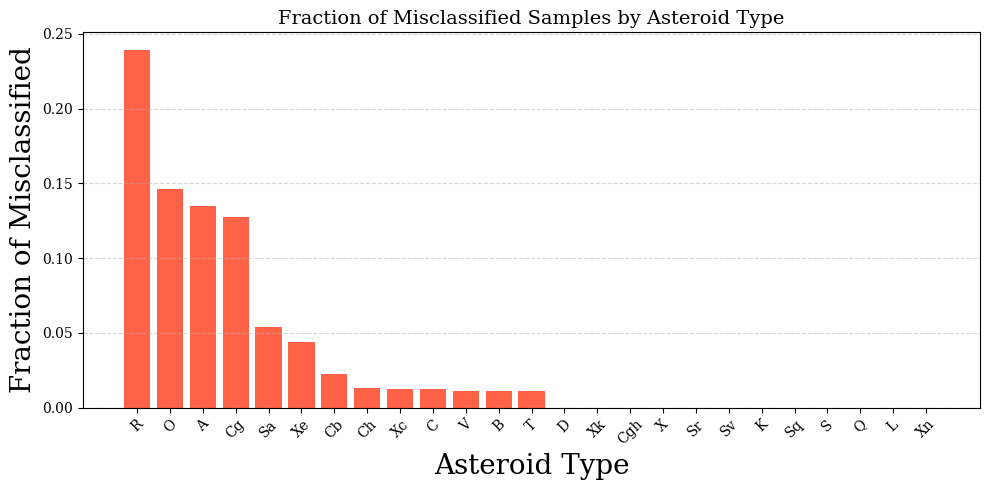

In [56]:

plt.figure(figsize=(10, 5))
plt.bar(df_fraction["Type"], df_fraction["Wrong_Fraction"], color='tomato')
plt.ylabel("Fraction of Misclassified")
plt.xlabel("Asteroid Type")
plt.title("Fraction of Misclassified Samples by Asteroid Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
